# 06 — Financial Business Case

Business case based on Model 1 tier-level marginal effects (interaction logit).
Compares blanket rollout vs a configurable targeted rollout by segment variable and segment values (default: internet usage = Extreme).

In [14]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Targeting parameters (edit here)
SEGMENT_VARIABLE = "internet_usage"
TARGET_SEGMENT = "Extreme"

try:
    from helpers import load_analysis_data, prepare_model_data
except ModuleNotFoundError:
    import sys
    from pathlib import Path
    sys.path.append(str((Path.cwd() / "notebooks").resolve()))
    from helpers import load_analysis_data, prepare_model_data

df = load_analysis_data()
df_clean = prepare_model_data(df)

In [15]:
formula_interaction = (
    "churned ~ has_booster * C(internet_usage) + age + tenure + "
    "C(tv_product) + C(mobile_product) + C(commune)"
)
fit = smf.logit(formula=formula_interaction, data=df_clean).fit(disp=False)

f1 = df_clean.copy(); f0 = df_clean.copy()
f1["has_booster"] = 1; f0["has_booster"] = 0
ite = fit.predict(f1) - fit.predict(f0)
df_clean["ite_churn"] = ite

tier_effects = df_clean.groupby(SEGMENT_VARIABLE, observed=True)["ite_churn"].mean()
tier_fin = tier_effects.to_frame(name="mean")
tier_fin["prevented_rate"] = (-tier_fin["mean"]).clip(lower=0.0)

N_CUSTOMERS_TOTAL = 1_500_000
VALUE_PER_PREVENTED_CHURN = 1800.0
BOOSTER_COST = 35.0

segment_mix = df_clean[SEGMENT_VARIABLE].value_counts(normalize=True).sort_index()
tier_fin["mix"] = segment_mix
tier_fin["population"] = tier_fin["mix"] * N_CUSTOMERS_TOTAL
tier_fin["revenue_saved_chf"] = tier_fin["population"] * tier_fin["prevented_rate"] * VALUE_PER_PREVENTED_CHURN
tier_fin["cost_chf"] = tier_fin["population"] * BOOSTER_COST
tier_fin["net_roi_chf"] = tier_fin["revenue_saved_chf"] - tier_fin["cost_chf"]

blanket_cost = float(tier_fin["cost_chf"].sum())
blanket_saved = float(tier_fin["revenue_saved_chf"].sum())
blanket_net = blanket_saved - blanket_cost

available_segments = set(tier_fin.index.astype(str))
if TARGET_SEGMENT not in available_segments:
    raise ValueError(
        f"Target segment '{TARGET_SEGMENT}' not found for {SEGMENT_VARIABLE}. "
        f"Available: {sorted(available_segments)}"
    )

targeted = tier_fin.loc[[TARGET_SEGMENT]].copy()
target_cost = float(targeted["cost_chf"].sum())
target_saved = float(targeted["revenue_saved_chf"].sum())
target_net = target_saved - target_cost

target_scenario_label = f"Targeted ({SEGMENT_VARIABLE}: {TARGET_SEGMENT})"

print("Blanket rollout:")
print(f"  Cost: CHF {blanket_cost:,.0f}")
print(f"  Saved revenue: CHF {blanket_saved:,.0f}")
print(f"  Net: CHF {blanket_net:,.0f}")

print(f"\n{target_scenario_label}:")
print(f"  Cost: CHF {target_cost:,.0f}")
print(f"  Saved revenue: CHF {target_saved:,.0f}")
print(f"  Net: CHF {target_net:,.0f}")

if target_net > blanket_net:
    print("\nRecommendation: Targeted rollout dominates blanket rollout.")
else:
    print("\nRecommendation: Blanket rollout is at least as good as targeted rollout.")

Blanket rollout:
  Cost: CHF 52,500,000
  Saved revenue: CHF 30,536,976
  Net: CHF -21,963,024

Targeted (internet_usage: Extreme):
  Cost: CHF 8,693,580
  Saved revenue: CHF 29,362,645
  Net: CHF 20,669,065

Recommendation: Targeted rollout dominates blanket rollout.


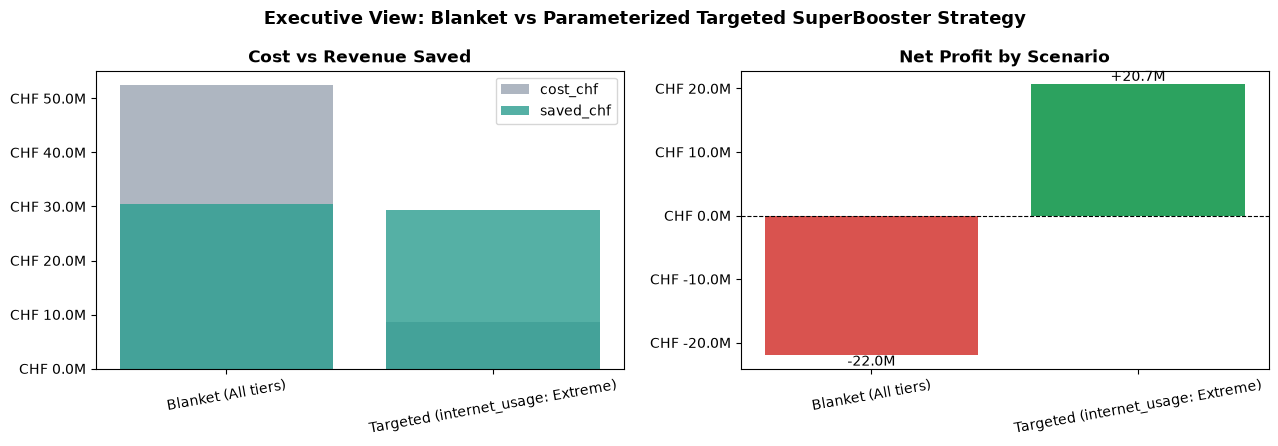

In [16]:
scenario_df = pd.DataFrame({
    "scenario": ["Blanket (All tiers)", target_scenario_label],
    "cost_chf": [blanket_cost, target_cost],
    "saved_chf": [blanket_saved, target_saved],
    "net_chf": [blanket_net, target_net],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot1 = scenario_df.melt(id_vars="scenario", value_vars=["cost_chf", "saved_chf"], var_name="metric", value_name="value")
axes[0].set_title("Cost vs Revenue Saved", fontweight="bold")
for m, c in [("cost_chf", "#9aa4b2"), ("saved_chf", "#2a9d8f")]:
    sub = plot1[plot1["metric"] == m]
    axes[0].bar(sub["scenario"], sub["value"], alpha=0.8, label=m, color=c)
axes[0].tick_params(axis="x", rotation=10)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"CHF {x/1e6:.1f}M"))
axes[0].legend()

colors = ["#d9534f" if v < 0 else "#2ca25f" for v in scenario_df["net_chf"]]
bars = axes[1].bar(scenario_df["scenario"], scenario_df["net_chf"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Net Profit by Scenario", fontweight="bold")
axes[1].tick_params(axis="x", rotation=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"CHF {x/1e6:.1f}M"))
for b, val in zip(bars, scenario_df["net_chf"]):
    axes[1].text(b.get_x() + b.get_width()/2, val, f"{val/1e6:+.1f}M", ha="center", va="bottom" if val >= 0 else "top", fontsize=10)

fig.suptitle("Executive View: Blanket vs Parameterized Targeted SuperBooster Strategy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()